# Exploration de la base prospects chauds

Notebook interactif pour observer, filtrer et visualiser `prospect_chauds.xlsx` — 19 533 établissements scolaires qualifiés **Chauds**.

Colonnes : `nom`, `type`, `localisation`, `site_web`, `email`, `telephone`, `pays`, `score`, `domaine`, `site_valide`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
print('OK')

OK


## 1. Chargement

In [2]:
df = pd.read_excel('data/prospect_chauds.xlsx')
print(f'{df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Colonnes: {list(df.columns)}')

19,533 lignes x 10 colonnes
Colonnes: ['nom', 'type', 'localisation', 'site_web', 'email', 'telephone', 'pays', 'score', 'domaine', 'site_valide']


## 2. Aperçu général

In [3]:
df.head(10)

,nom,type,localisation,site_web,email,telephone,pays,score,domaine,site_valide
0,Collège Don Bosco,Privé,"Nice, Alpes-Maritimes",http://www.fondation-donbosco.fr,apeldb06@gmail.com | info@donbosconice.eu | j....,04 93 92 85 85,France,98,fondation-donbosco.fr,Oui
1,"Collège l'Ermitage, École internationale de Fr...",Privé,"Maisons-Laffitte, Yvelines",http://www.ermitage.fr/index.cfm,admissions@ermitage.fr,01 39 62 09 54,France,98,ermitage.fr,Oui
2,Lycée Steiner,Privé,"Verrières-le-Buisson, Essonne",http://ecole-steiner-verrieres.org,accueil@ecole-steiner-verrieres.org | caissede...,01 60 11 38 12,France,98,ecole-steiner-verrieres.org,Oui
3,Lycée professionnel Jean-Baptiste d'Allard Don...,Privé,"Montbrison, Loire",https://www.jbdallard.com,contact@jbdallard.com,04 77 58 15 89,France,97,jbdallard.com,Oui
4,Collège Adventiste Rama,Privé,"Sainte-Luce, Martinique",https://csarama.org,contact@csarama.org | rama.doc@csarama.org,05 96 62 51 93,France,97,csarama.org,Oui
5,Lycée privé Don Bosco,Privé,"Wittenheim, Haut-Rhin",https://www.donboscowit.eu,apprentissage@donboscowit.eu | contact@donbosc...,03 89 52 62 25,France,97,donboscowit.eu,Oui
6,Lycée le Puits de l'Aune Don Bosco,Privé,"Feurs, Loire",https://lepuitsdelaune.fr,feurs@cneap.fr,04 77 26 11 65,France,97,lepuitsdelaune.fr,Oui
7,Lycée professionnel Don Bosco,Privé,"Lyon, Rhône",https://www.donboscolyon.org,accueil@donboscolyon.org | lycee@donboscolyon.org,04 72 41 14 54,France,97,donboscolyon.org,Oui
8,Lycée Don Bosco,Privé,"Mayenne, Mayenne",https://donboscomayenne.fr/lycee-general,lavallee@dbosco.fr | lycee.professionnel@donbo...,02 43 30 47 47,France,97,donboscomayenne.fr,Oui
9,Lycée professionnel privé Don Bosco,Privé,"Pirae, Polynésie Française",https://www.donbosco-tahiti.pf,pcgraphiste@gmail.com | secdir@donbosco.ddec.pf,40 54 86 60,France,97,donbosco-tahiti.pf,Oui


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19533 entries, 0 to 19532
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nom           19533 non-null  object
 1   type          19533 non-null  object
 2   localisation  19533 non-null  object
 3   site_web      13425 non-null  object
 4   email         18661 non-null  object
 5   telephone     17913 non-null  object
 6   pays          19533 non-null  object
 7   score         19533 non-null  int64 
 8   domaine       13425 non-null  object
 9   site_valide   13425 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.5+ MB


In [5]:
pd.DataFrame({'# nuls': df.isnull().sum(), '% nuls': (df.isnull().sum() / len(df) * 100).round(1)})

,# nuls,% nuls
nom,0,0.0
type,0,0.0
localisation,0,0.0
site_web,6108,31.3
email,872,4.5
telephone,1620,8.3
pays,0,0.0
score,0,0.0
domaine,6108,31.3
site_valide,6108,31.3


## 3. Analyse des emails

In [6]:
def count_emails(v):
    if pd.isna(v) or v == '':
        return 0
    return len(str(v).split(' | '))

def has_ce(v):
    return bool(re.match(r'^ce\.\w+@ac-', str(v)))

df['_nb_emails'] = df['email'].apply(count_emails)
df['_is_ce'] = df['email'].apply(lambda e: bool(re.match(r'^ce\.\w+@ac-', str(e))) if pd.notna(e) else False)

total = len(df)
avec = df['email'].notna().sum()
multi = (df['_nb_emails'] > 1).sum()
ce_only = df[(df['_is_ce']) & (df['_nb_emails'] == 1)].shape[0]
sans = (df['email'].isna() | (df['email'] == '')).sum()

print(f'Total lignes: {total:,}')
print(f'Avec email: {avec:,} ({avec/total*100:.1f}%)')
print(f'Multiples emails: {multi:,} ({multi/total*100:.1f}%)')
print(f'ce.xxx seuls: {ce_only:,} ({ce_only/total*100:.1f}%)')
print(f'Sans email: {sans:,} ({sans/total*100:.1f}%)')

Total lignes: 19,533
Avec email: 18,661 (95.5%)
Multiples emails: 1,767 (9.0%)
ce.xxx seuls: 9,949 (50.9%)
Sans email: 872 (4.5%)


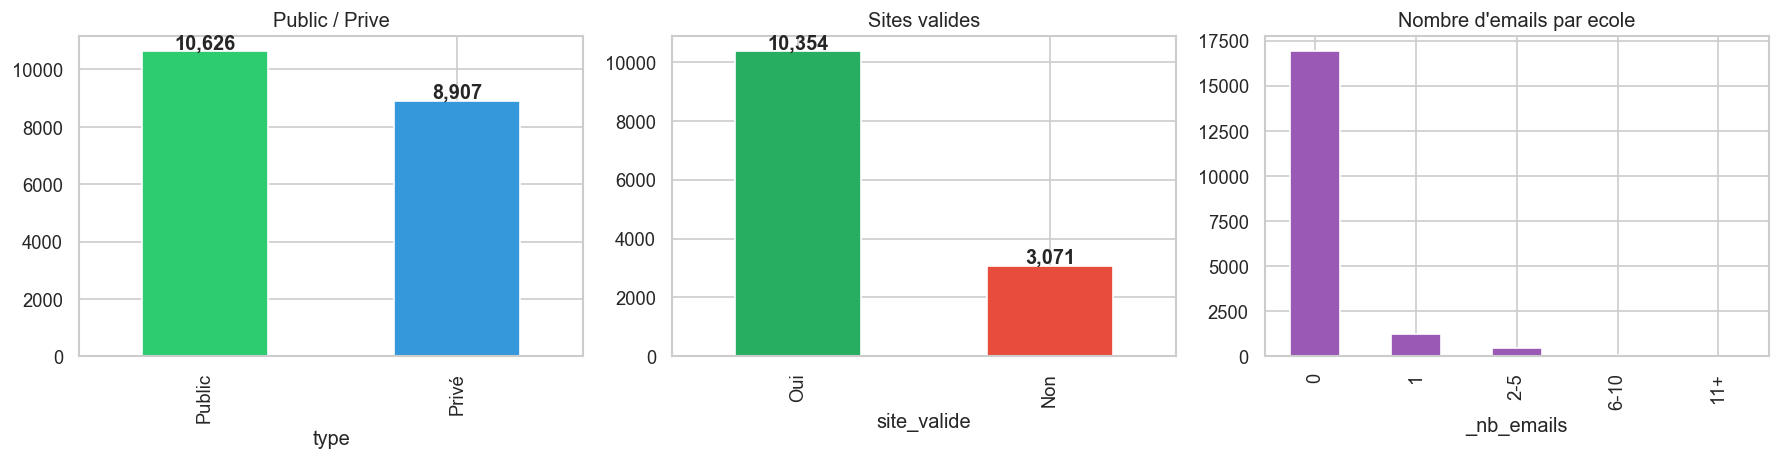

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['type'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db'])
axes[0].set_title('Public / Prive')
for i, v in enumerate(df['type'].value_counts()):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

df['site_valide'].value_counts().plot(kind='bar', ax=axes[1], color=['#27ae60', '#e74c3c'])
axes[1].set_title('Sites valides')
for i, v in enumerate(df['site_valide'].value_counts()):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

nb_cats = pd.cut(df['_nb_emails'], bins=[0, 1, 2, 5, 10, 100], labels=['0', '1', '2-5', '6-10', '11+'])
nb_cats.value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#9b59b6')
axes[2].set_title('Nombre d\'emails par ecole')

plt.tight_layout()
plt.show()

In [ ]:
# Exemples avec multiples emails
multi = df[df['_nb_emails'] > 1].head(15)
print(f'Ecoles avec plusieurs emails ({len(multi)} affichees):')
multi[['nom', 'type', 'email', 'score']]

## 4. Visualisations

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(df['score'], bins=range(50, 105, 5), edgecolor='white', color='#9b59b6')
axes[0].set_title('Distribution des scores')
axes[0].set_xlabel('Score')

sns.boxplot(data=df, x='type', y='score', ax=axes[1], palette=['#2ecc71', '#3498db'])
axes[1].set_title('Score par type')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2)

top_pays = df['pays'].value_counts().head(15)
axes[0].barh(range(len(top_pays)), top_pays.values, color='#1abc9c')
axes[0].set_yticks(range(len(top_pays)))
axes[0].set_yticklabels(top_pays.index)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 pays')

top_loc = df['localisation'].value_counts().head(15)
axes[1].barh(range(len(top_loc)), top_loc.values, color='#e67e22')
axes[1].set_yticks(range(len(top_loc)))
axes[1].set_yticklabels([l[:30] for l in top_loc.index])
axes[1].invert_yaxis()
axes[1].set_title('Top 15 localisations')

plt.tight_layout()
plt.show()

In [ ]:
top_domaines = df['domaine'].dropna().str.lower().str.replace(r'^www\.', '', regex=True).value_counts().head(20)
plt.figure(figsize=(12, 5))
top_domaines.plot(kind='bar', color='#8e44ad')
plt.title('Top 20 domaines')
plt.ylabel('Nombre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Filtre interactif

In [ ]:
# --- Parametres modifiables ---
TYPE_FILTER = 'Prive'       # 'Prive', 'Public', ou None
SCORE_MIN = 80
SITE_VALIDE = 'Oui'         # 'Oui', 'Non', ou None
PAYS = 'France'             # ou None
MAX_LIGNES = 20
# ------------------------------

filtre = df.copy()
if TYPE_FILTER: filtre = filtre[filtre['type'] == TYPE_FILTER]
if SITE_VALIDE: filtre = filtre[filtre['site_valide'] == SITE_VALIDE]
if PAYS: filtre = filtre[filtre['pays'] == PAYS]
filtre = filtre[filtre['score'] >= SCORE_MIN]

print(f'{len(filtre):,} lignes sur {len(df):,}')
filtre.head(MAX_LIGNES)

In [ ]:
# Export du filtre en CSV (decommente pour exporter)
# filtre.to_csv('export_filtre.csv', index=False)
# print('Exporte vers export_filtre.csv')

## 6. Stats complementaires

In [ ]:
completion = pd.DataFrame({
    'colonne': df.columns,
    'remplies': df.notna().sum().values,
    'taux': (df.notna().sum() / len(df) * 100).round(1).values
}).sort_values('taux', ascending=False)
completion

In [ ]:
# Meilleurs prospects: Prives avec site valide + email
top = df[(df['type'] == 'Prive') & (df['site_valide'] == 'Oui') & (df['email'].notna()) & (df['email'] != '')]
print(f'Prives avec site + email: {len(top):,}')
top[['nom', 'email', 'score']].head(20)

In [ ]:
top_pub = df[(df['type'] == 'Public') & (df['site_valide'] == 'Oui') & (df['email'].notna()) & (df['email'] != '')]
print(f'Publics avec site + email: {len(top_pub):,}')
top_pub[['nom', 'email', 'score']].head(20)

---
*Base `prospect_chauds.xlsx` (19 533 lignes, 10 colonnes) — Genere le 2026-06-13*